In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
sys.path.append("../src")

from config import DATA_PATH, SCENARIOS_PATH 
from choice_model import scale_attribute 
from load_data import load_scenarios, load_beta_partworths_samples, load_beta_partworths_mean

In [3]:
beta_means = load_beta_partworths_mean(str(DATA_PATH))

In [4]:
scenarios_data = load_scenarios(str(SCENARIOS_PATH))
scenarios_data

,scenario,cost_change_pct_vs_ep2050,fuel_imports_twh,gross_winter_imports_twh,buildings_heat_electrification_pct,materials_land_concern,public_acceptance_note,land_use_km2_approx,land_use_precision,source
0,EP2050+,0.0,9.1,24.7,36.3,n.a.,5% for electricity imports,67.0,approximate (read from Figure 1S bar chart),Table 3 (main text); Figure 1S (supplementary)
1,EP2050+ (5TWh constraint),64.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Table 1 and main text (main text); not reporte...
2,S/CCGT (Fossil) + DACCS,-16.3,31.8,25.3,100.0,NaN,25% for natural gas,67.0,approximate (read from Figure 1S bar chart),Table 3 (main text); Figure 1S (supplementary)
3,S/CCGT (Ren. Methane) + H2,-3.6,0.0,24.4,100.0,NaN,66% for biomass,67.0,approximate (read from Figure 1S bar chart),Table 3 (main text); Figure 1S (supplementary)
4,S/CCGT (Ren. Methane),-3.6,0.0,24.4,100.0,NaN,66% for biomass,67.0,approximate (read from Figure 1S bar chart),Table 3 (main text); Figure 1S (supplementary)
5,Alpine PV,-0.8,0.0,24.0,56.4,"Land use, Graphite",56% for open-field PV,128.0,approximate (read from Figure 1S bar chart),Table 3 (main text); Figure 1S (supplementary)
6,Wind,18.0,16.3,22.7,32.4,PGM,60%,72.0,approximate (read from Figure 1S bar chart),Table 3 (main text); Figure 1S (supplementary)
7,Roof PV++,33.7,17.8,22.5,32.4,"Graphite, PGM",90%,72.0,approximate (read from Figure 1S bar chart),Table 3 (main text); Figure 1S (supplementary)
8,CHP,22.2,17.4,23.2,33.5,NaN,NaN,72.0,approximate (read from Figure 1S bar chart),Table 3 (main text); Figure 1S (supplementary)
9,H2 Imports,19.2,18.7,22.3,3.0,PGM,NaN,67.0,approximate (read from Figure 1S bar chart),Table 3 (main text); Figure 1S (supplementary)


In [5]:
scenario_data_alpine_pv = scenarios_data[scenarios_data["scenario"] == "Alpine PV"]
scenario_data_alpine_pv

,scenario,cost_change_pct_vs_ep2050,fuel_imports_twh,gross_winter_imports_twh,buildings_heat_electrification_pct,materials_land_concern,public_acceptance_note,land_use_km2_approx,land_use_precision,source
5,Alpine PV,-0.8,0.0,24.0,56.4,"Land use, Graphite",56% for open-field PV,128.0,approximate (read from Figure 1S bar chart),Table 3 (main text); Figure 1S (supplementary)


In [6]:
SWISS_LAND_AREA_KM2 = 41_285  # total land area of Switzerland

land_km2 = scenario_data_alpine_pv["land_use_km2_approx"].iloc[0]
land_share = land_km2 / SWISS_LAND_AREA_KM2
land_share

np.float64(0.003100399660893787)

In [7]:
land_scaled = scale_attribute(land_share, "LAND")
land_scaled

np.float64(0.038754995761172334)

In [8]:
price_raw_decimal = scenario_data_alpine_pv["cost_change_pct_vs_ep2050"].iloc[0] / 100
price_scaled = scale_attribute(price_raw_decimal, "PRICES")

price_scaled

np.float64(-0.013333333333333334)

In [9]:
share_imports = 0 #placeholder for now, since i will need acctual data

In [10]:
x_alpine_pv = {
    "TECHNOLOGY:Open-field PV": 1,
    "TECHNOLOGY:Wind":0, 
    "TRANSMISSION":0,
    "LAND": land_scaled,
    "SHARE_IMPORTS": share_imports, 
    "PRICES": price_scaled,
}
x_alpine_pv

{'TECHNOLOGY:Open-field PV': 1,
 'TECHNOLOGY:Wind': 0,
 'TRANSMISSION': 0,
 'LAND': np.float64(0.038754995761172334),
 'SHARE_IMPORTS': 0,
 'PRICES': np.float64(-0.013333333333333334)}

In [11]:
beta_means

,attribute,beta_mean
0,TECHNOLOGY:Open-field PV,-0.198433
1,TECHNOLOGY:Wind,-0.432109
2,TRANSMISSION,-0.105768
3,LAND,-0.094972
4,SHARE_IMPORTS,-0.654340
5,PRICES,-1.163388


In [12]:
utility_alpine_pv = sum(x_alpine_pv[attr] * beta_means[beta_means["attribute"] == attr]["beta_mean"].values[0] for attr in x_alpine_pv)
utility_alpine_pv

np.float64(-0.18660205858649836)

In [13]:
for attr in x_alpine_pv:
    beta_val = beta_means[beta_means["attribute"] == attr]["beta_mean"].values[0]
    contribution = x_alpine_pv[attr] * beta_val
    print(f"{attr}: x={x_alpine_pv[attr]:.4f}, beta={beta_val:.4f}, contribution={contribution:.4f}")
    

TECHNOLOGY:Open-field PV: x=1.0000, beta=-0.1984, contribution=-0.1984
TECHNOLOGY:Wind: x=0.0000, beta=-0.4321, contribution=-0.0000
TRANSMISSION: x=0.0000, beta=-0.1058, contribution=-0.0000
LAND: x=0.0388, beta=-0.0950, contribution=-0.0037
SHARE_IMPORTS: x=0.0000, beta=-0.6543, contribution=-0.0000
PRICES: x=-0.0133, beta=-1.1634, contribution=0.0155


In [14]:
scenario_data_ep2050 = scenarios_data[scenarios_data["scenario"] == "EP2050+"]
scenario_data_ep2050

,scenario,cost_change_pct_vs_ep2050,fuel_imports_twh,gross_winter_imports_twh,buildings_heat_electrification_pct,materials_land_concern,public_acceptance_note,land_use_km2_approx,land_use_precision,source
0,EP2050+,0.0,9.1,24.7,36.3,n.a.,5% for electricity imports,67.0,approximate (read from Figure 1S bar chart),Table 3 (main text); Figure 1S (supplementary)


In [15]:
land_share_ep2050 = scenario_data_ep2050["land_use_km2_approx"].iloc[0] / SWISS_LAND_AREA_KM2
land_scaled_ep2050 = scale_attribute(land_share_ep2050, "LAND")
land_scaled_ep2050

np.float64(0.020285818093738646)

In [16]:
price_raw_decimal_ep2050 = scenario_data_ep2050["cost_change_pct_vs_ep2050"].iloc[0] / 100
price_scaled_ep2050 = scale_attribute(price_raw_decimal_ep2050, "PRICES")
price_scaled_ep2050

np.float64(0.0)

In [17]:
share_imports_ep2050 = 0 #placeholder for now, since i will need acctual data

In [18]:
x_ep2050 = {
    "TECHNOLOGY:Open-field PV": 0,
    "TECHNOLOGY:Wind":0,
    "TRANSMISSION":0,
    "LAND": land_scaled_ep2050,
    "SHARE_IMPORTS": share_imports_ep2050,
    "PRICES": price_scaled_ep2050,
}
x_ep2050

{'TECHNOLOGY:Open-field PV': 0,
 'TECHNOLOGY:Wind': 0,
 'TRANSMISSION': 0,
 'LAND': np.float64(0.020285818093738646),
 'SHARE_IMPORTS': 0,
 'PRICES': np.float64(0.0)}

In [19]:
utility_ep2050 = sum(x_ep2050[attr] * beta_means[beta_means["attribute"] == attr]["beta_mean"].values[0] for attr in x_ep2050)
utility_ep2050

np.float64(-0.0019265771720467296)

In [20]:
from choice_model import compute_utility


In [21]:
alpine_pv_row = scenarios_data[scenarios_data["scenario"] == "Alpine PV"].iloc[0]
ep2050_row = scenarios_data[scenarios_data["scenario"] == "EP2050+"].iloc[0]

alpine_pv_utility = compute_utility(alpine_pv_row, beta_means, "Open-field PV")
ep2050_utility = compute_utility(ep2050_row, beta_means, "Rooftop PV")
alpine_pv_utility, ep2050_utility

({'utility': np.float64(-0.18660205858649836),
  'contributions': {'TECHNOLOGY:Open-field PV': np.float64(-0.1984332709864894),
   'TECHNOLOGY:Wind': np.float64(-0.0),
   'TRANSMISSION': np.float64(-0.0),
   'LAND': np.float64(-0.0036806250451041993),
   'SHARE_IMPORTS': np.float64(-0.0),
   'PRICES': np.float64(0.015511837445095234)}},
 {'utility': np.float64(-0.0019265771720467296),
  'contributions': {'TECHNOLOGY:Open-field PV': np.float64(-0.0),
   'TECHNOLOGY:Wind': np.float64(-0.0),
   'TRANSMISSION': np.float64(-0.0),
   'LAND': np.float64(-0.0019265771720467296),
   'SHARE_IMPORTS': np.float64(-0.0),
   'PRICES': np.float64(-0.0)}})

In [22]:
from choice_model import compute_probabilities

In [24]:
scenario_names = scenarios_data["scenario"].tolist()  # check exact names match your CSV

dominant_technology_by_scenario = {
    name: "Rooftop PV" for name in scenario_names
}

In [25]:
results = {}
for name, tech in dominant_technology_by_scenario.items():
    row = scenarios_data[scenarios_data["scenario"] == name].iloc[0]
    results[name] = compute_utility(row, beta_means, dominant_technology=tech)

for name, r in sorted(results.items(), key=lambda kv: kv[1]["utility"], reverse=True):
    print(f"{name}: {r['utility']:.4f}")
    

EP2050+ (5TWh constraint): nan
MIX: 0.3277
S/CCGT (Fossil) + DACCS: 0.3141
RE MIX: 0.1678
S/CCGT (Ren. Methane) + H2: 0.0679
S/CCGT (Ren. Methane): 0.0679
Alpine PV: 0.0118
EP2050+: -0.0019
Wind: -0.3511
H2 Imports: -0.3742
CHP: -0.4325
Roof PV++: -0.6555


In [ ]:
utilities = {name: r["utility"] for name, r in results.items() if not pd.isna(r["utility"])}

# alle gültigen Szenarien gegeneinander
probs_all = compute_probabilities(utilities)

# jedes Szenario einzeln gegen EP2050+ als Baseline
probs_vs_baseline = {
    name: compute_probabilities(utilities, choice_set=[name, "EP2050+"])
    for name in utilities if name != "EP2050+"
}

for name, p in sorted(probs_all.items(), key=lambda kv: kv[1], reverse=True):
    print(f"{name}: {p:.3f}")

MIX: 0.130
S/CCGT (Fossil) + DACCS: 0.129
RE MIX: 0.111
S/CCGT (Ren. Methane) + H2: 0.100
S/CCGT (Ren. Methane): 0.100
Alpine PV: 0.095
EP2050+: 0.094
Wind: 0.066
H2 Imports: 0.065
CHP: 0.061
Roof PV++: 0.049


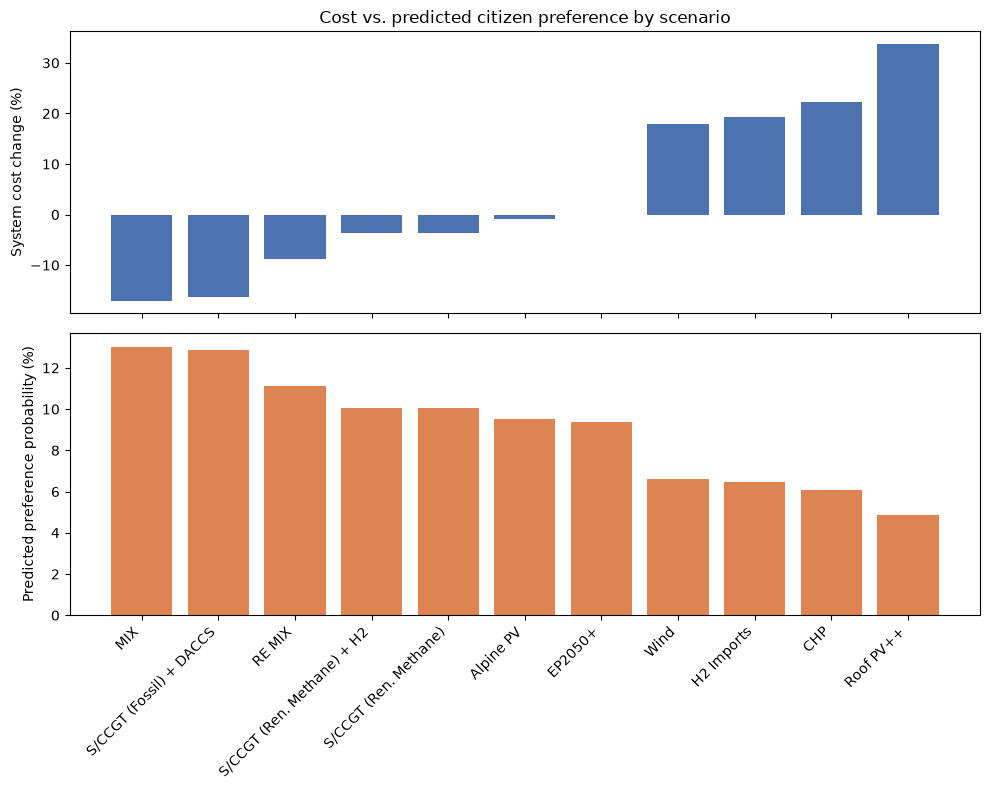

In [29]:
sorted_names = sorted(probs_all, key=lambda n: cost_by_scenario[n])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.bar(sorted_names, [cost_by_scenario[n] for n in sorted_names], color="#4C72B0")
ax1.set_ylabel("System cost change (%)")
ax1.set_title("Cost vs. predicted citizen preference by scenario")

ax2.bar(sorted_names, [probs_all[n] * 100 for n in sorted_names], color="#DD8452")
ax2.set_ylabel("Predicted preference probability (%)")
plt.setp(ax2.get_xticklabels(), rotation=45, ha="right")

fig.tight_layout()
fig.savefig("../graphics/cost_vs_preference.png", dpi=150)
plt.show()

# Status 22.09.2026

## Gemacht
- Pipeline: config.py (Konstanten), load_data.py (betas laden aus netcdf), choice_model.py (scale_attribute, compute_utility, compute_probabilities)
- Sanity check Alpine PV / EP2050+ manuell vs Funktion, exakt gleich
- Alle 12 Szenarien durchgerechnet (11 valide, 5TWh constraint fehlt Daten)

## Limitationen
- Technology immer rooftop PV, egal ob capacity oder generation, jährlich. Winter evtl fix, aber keine daten dazu
- Share imports = 0 platzhalter, keine jährlichen daten, nur gross winter imports
- Transmission = 0 platzhalter
- Prices: mellot rechnet relativ zu EP2050+, model braucht relativ zu heute?
- Manche preise ausserhalb umfragebereich (Alpine PV negativ), exprapolation also kein problem?
- NOT_SAMPLED = Schweiz, gestützt durch Norwegen im paper
- Ownership fehlt im modell komplett
- 5TWh constraint scenario fehlt daten in csv
- Ranking aktuell praktisch nur preis, weil rest noch platzhalter

## Nächste schritte
- Zu besprechen: siehe liste, meeting minutes
- Rohdaten bei mellot/adrien anfragen
- Pipeline neu laufen lassen sobald daten da